# Análisis del Mercado de Airbnb en Nueva York

## Pregunta de Negocio

¿Qué factores influyen en el precio y la popularidad de los alojamientos Airbnb en Nueva York?

## Objetivos

- Analizar la distribución de precios.
- Identificar diferencias entre boroughs.
- Evaluar el impacto del tipo de alojamiento en el precio.
- Analizar la relación entre precio y popularidad.
- Generar recomendaciones para anfitriones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/AB_NYC_2019.csv')

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
df.shape

(48895, 16)

# =================================
# 1. Data Inspection
# =================================

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Hallazgos preliminares:

- Hay 48,895 alojamientos.

- La mayoría de las columnas están completas.

- reviews_per_month y last_review tienen aproximadamente 10,000 valores faltantes, lo cual probablemente significa que esos alojamientos nunca han recibido reseñas.

- Hay precios desde $0 hasta $10,000, lo que sugiere posibles outliers que tendremos que revisar.

# =================================
# 2. Data Cleaning
# =================================

In [6]:
df[df['price'] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaN,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [7]:
len(df[df['price'] == 0])

11

In [8]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

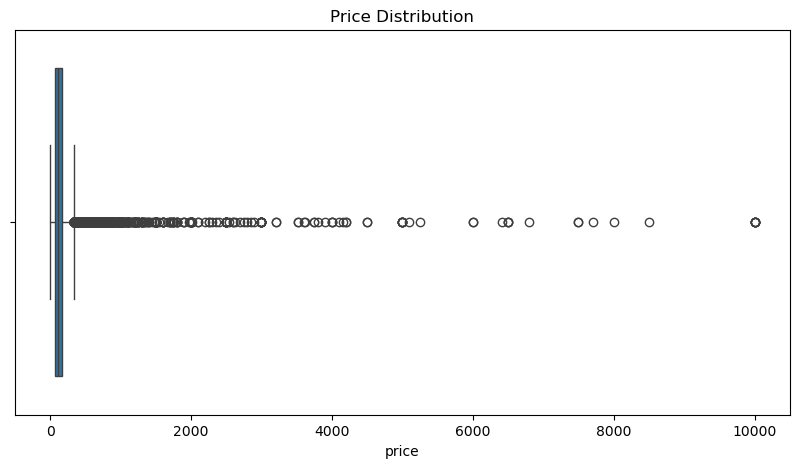

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title('Price Distribution')
plt.show()

La distribución de precios muestra una fuerte concentración de alojamientos en rangos de precio relativamente bajos, mientras que existe un pequeño grupo de propiedades con precios extremadamente altos. Estos valores atípicos alcanzan hasta los $10,000 por noche y pueden distorsionar el análisis estadístico. Por esta razón, se decidió eliminar el 1% de los precios más altos para obtener una representación más precisa del mercado típico de Airbnb en Nueva York. Además, se identificaron 11 alojamientos con precio de $0, los cuales podrían corresponder a errores de captura o anuncios inactivos.

In [10]:
price_limit = df['price'].quantile(0.99)

price_limit

np.float64(799.0)

In [11]:
df_clean = df[df['price'] <= price_limit].copy()

df_clean.shape

(48421, 16)

In [12]:
borough_prices = (
    df_clean.groupby('neighbourhood_group')['price']
    .mean()
    .sort_values(ascending=False)
)

borough_prices

neighbourhood_group
Manhattan        172.893774
Brooklyn         115.869357
Staten Island     94.241192
Queens            94.104779
Bronx             83.785846
Name: price, dtype: float64

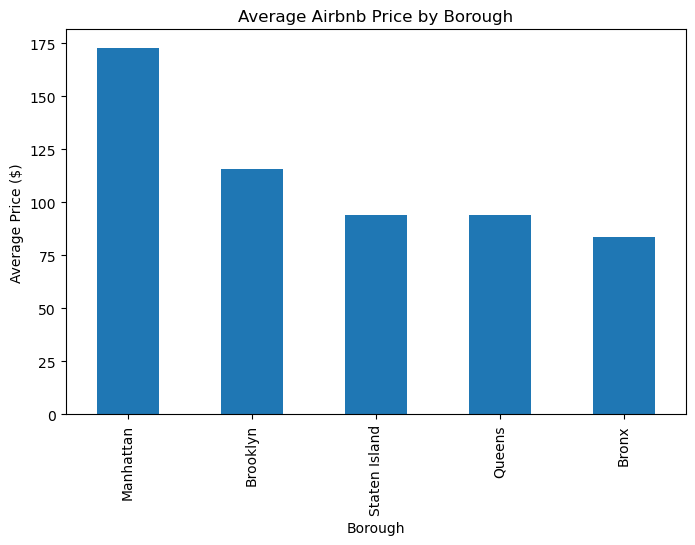

In [13]:
plt.figure(figsize=(8,5))

borough_prices.plot(kind='bar')

plt.title('Average Airbnb Price by Borough')
plt.ylabel('Average Price ($)')
plt.xlabel('Borough')

plt.show()

Manhattan presenta el precio promedio más alto ($172.89 por noche), superando significativamente a los demás boroughs. Brooklyn ocupa el segundo lugar con un promedio de $115.87, mientras que Staten Island, Queens y Bronx muestran precios considerablemente más bajos. Estos resultados sugieren que la ubicación es uno de los factores más importantes en la determinación del precio de un alojamiento, siendo Manhattan la zona premium del mercado debido a su alta demanda turística y proximidad a los principales puntos de interés de la ciudad.

Insight: Un nuevo anfitrión que busque maximizar ingresos podría considerar propiedades ubicadas en Manhattan o Brooklyn. Sin embargo, los boroughs con precios más bajos podrían representar oportunidades para competir mediante una estrategia de valor, atrayendo huéspedes que buscan opciones más económicas.

In [15]:
room_type_counts = df_clean['room_type'].value_counts()

room_type_counts

room_type
Entire home/apt    25024
Private room       22244
Shared room         1153
Name: count, dtype: int64

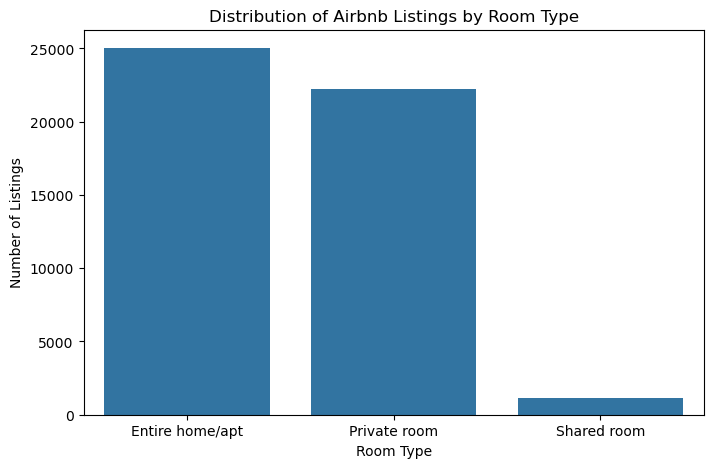

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='room_type',
    order=df_clean['room_type'].value_counts().index
)

plt.title('Distribution of Airbnb Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')

plt.show()

La mayor parte de los anuncios de Airbnb en Nueva York corresponden a alojamientos completos (Entire home/apartment), con 25,024 propiedades registradas. En segundo lugar se encuentran las habitaciones privadas (Private room), con 22,244 anuncios. Por el contrario, las habitaciones compartidas (Shared room) representan una proporción muy pequeña del mercado, con solo 1,153 registros.

Estos resultados indican que la oferta de Airbnb en Nueva York está enfocada principalmente en viajeros que buscan privacidad y comodidad, ya sea mediante el alquiler de una propiedad completa o de una habitación privada. Las habitaciones compartidas constituyen un nicho reducido dentro de la plataforma.

Insight: Los anfitriones que ofrecen propiedades completas tienen acceso al segmento más demandado del mercado. Sin embargo, las habitaciones privadas representan una alternativa competitiva para propietarios que buscan generar ingresos adicionales sin destinar toda la vivienda al alquiler turístico.

In [17]:
avg_price_room = (
    df_clean.groupby('room_type')['price']
    .mean()
    .sort_values(ascending=False)
)

avg_price_room

room_type
Entire home/apt    189.085158
Private room        83.368504
Shared room         64.091934
Name: price, dtype: float64

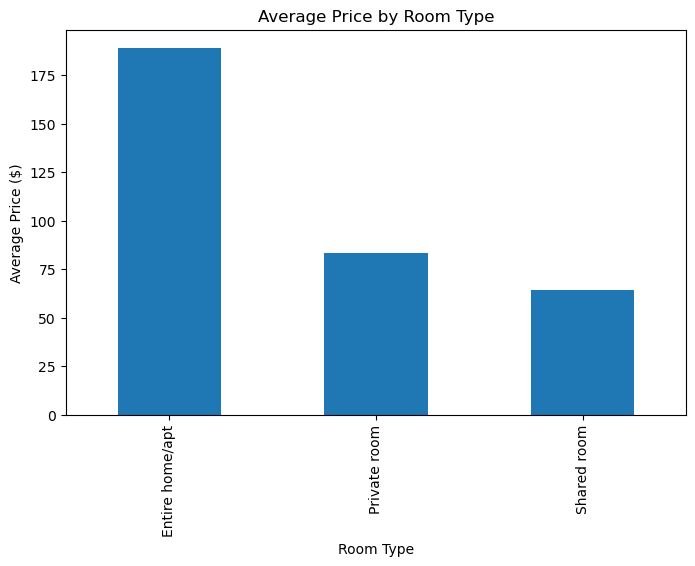

In [18]:
plt.figure(figsize=(8,5))

avg_price_room.plot(kind='bar')

plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price ($)')

plt.show()

Los alojamientos completos (Entire home/apartment) presentan el precio promedio más alto del mercado, con aproximadamente $189 por noche, más del doble que las habitaciones privadas ($83) y casi tres veces el precio de las habitaciones compartidas ($64).

Esta diferencia refleja el valor que los huéspedes asignan a la privacidad y al uso exclusivo de una propiedad. Mientras que las habitaciones privadas y compartidas están orientadas a viajeros con presupuestos más ajustados, los alojamientos completos compiten en segmentos de mayor valor y generan ingresos potencialmente más altos por reserva.

Insight: Para maximizar ingresos por reserva, los anfitriones pueden beneficiarse de ofrecer alojamientos completos. Sin embargo, las habitaciones privadas representan una alternativa más accesible para quienes desean monetizar una propiedad sin asumir los costos o la logística de dedicar una vivienda completa al alquiler turístico.

In [19]:
reviews_by_borough = (
    df_clean.groupby('neighbourhood_group')['number_of_reviews']
    .mean()
    .sort_values(ascending=False)
)

reviews_by_borough

neighbourhood_group
Staten Island    31.276423
Queens           27.753451
Bronx            26.075368
Brooklyn         24.271786
Manhattan        21.189227
Name: number_of_reviews, dtype: float64

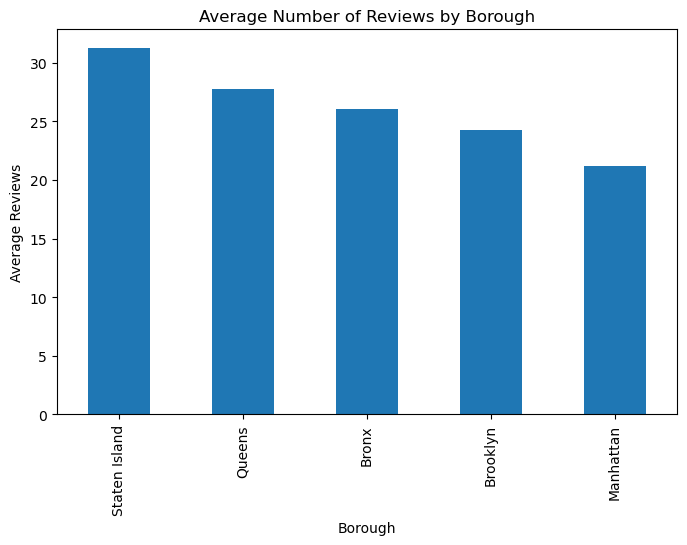

In [20]:
plt.figure(figsize=(8,5))

reviews_by_borough.plot(kind='bar')

plt.title('Average Number of Reviews by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Reviews')

plt.show()

Staten Island presenta el promedio más alto de reseñas por alojamiento (31.3 reseñas), seguido por Queens (27.8) y Bronx (26.1). Por otro lado, Manhattan registra el promedio más bajo (21.2 reseñas) a pesar de tener los precios más elevados del mercado.

Este hallazgo sugiere que los alojamientos ubicados en boroughs con precios más accesibles podrían generar una mayor rotación de huéspedes, lo que se traduce en un mayor número de reseñas. En contraste, los precios más altos de Manhattan podrían limitar la frecuencia de reservas, reduciendo la cantidad promedio de opiniones por anuncio.

Insight: Un precio más alto no necesariamente implica mayor demanda. Los anfitriones ubicados en Queens, Bronx o Staten Island podrían beneficiarse de una estrategia basada en volumen de reservas, mientras que Manhattan parece operar bajo un modelo de mayor ingreso por reserva pero menor cantidad de huéspedes.

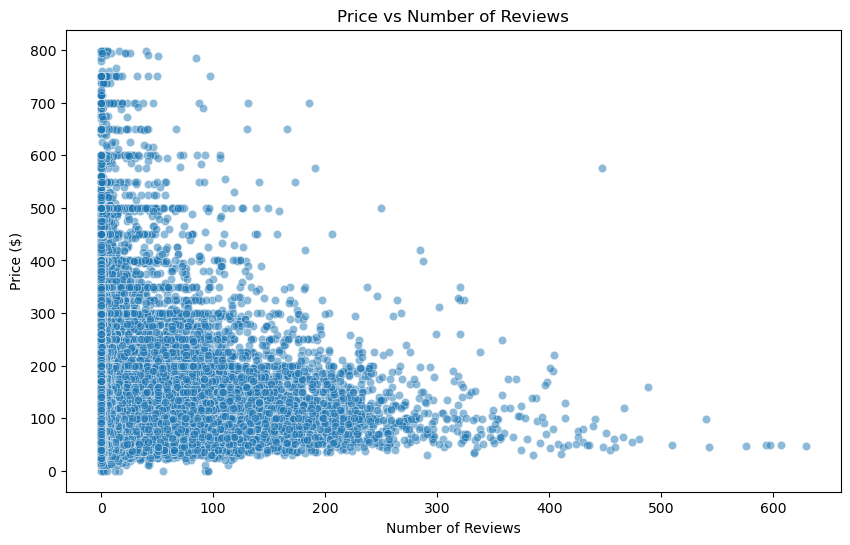

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='number_of_reviews',
    y='price',
    alpha=0.5
)

plt.title('Price vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price ($)')

plt.show()

La dispersión de los datos muestra una relación inversa moderada entre el precio y el número de reseñas. Los alojamientos con mayor cantidad de opiniones tienden a concentrarse en rangos de precio bajos y medios, mientras que las propiedades más costosas suelen acumular menos reseñas.

También se observa una gran variabilidad en los precios cuando el número de reseñas es bajo, lo que indica que los nuevos anuncios o los alojamientos menos populares pueden pertenecer a segmentos de mercado muy distintos. Sin embargo, conforme aumenta el número de reseñas, los precios tienden a concentrarse en niveles más moderados.

Insight: La popularidad parece estar más asociada con precios accesibles que con precios premium. Los anfitriones que buscan aumentar la ocupación y la cantidad de reseñas podrían beneficiarse de una estrategia de precios competitiva, especialmente durante las primeras etapas de publicación de un alojamiento.

# Conclusiones

Este análisis exploró el mercado de Airbnb en la ciudad de Nueva York utilizando cerca de 49,000 alojamientos registrados en la plataforma.

Los principales hallazgos fueron los siguientes:

* Manhattan presenta los precios promedio más altos, posicionándose como el segmento premium del mercado.
* Los alojamientos completos (*Entire home/apartment*) son el tipo de propiedad más común y también el que alcanza los precios promedio más elevados.
* Boroughs como Queens y Staten Island presentan una mayor cantidad promedio de reseñas por alojamiento, lo que podría indicar una mayor rotación de huéspedes.
* Los alojamientos con precios bajos y medios tienden a acumular más reseñas que aquellos con precios elevados.
* La ubicación y el tipo de alojamiento son factores clave en la determinación del precio de una propiedad dentro de Airbnb.

# Recomendaciones de negocio

Con base en los resultados obtenidos, se proponen las siguientes recomendaciones:

1. Los nuevos anfitriones pueden beneficiarse de una estrategia de precios competitiva para aumentar la ocupación y generar reseñas durante las primeras etapas de operación.

2. Los anfitriones ubicados en Manhattan pueden enfocarse en maximizar el ingreso por reserva, aprovechando la disposición de los huéspedes a pagar tarifas más altas.

3. Las habitaciones privadas representan una alternativa atractiva para propietarios que desean generar ingresos adicionales sin destinar una vivienda completa al alquiler turístico.

4. El monitoreo constante de las reseñas y la ocupación puede ayudar a encontrar un equilibrio adecuado entre rentabilidad y demanda.

# Limitaciones del análisis

* El conjunto de datos corresponde a un momento específico en el tiempo y puede no reflejar cambios recientes en el mercado.
* El análisis se centró principalmente en variables relacionadas con precio, ubicación y popularidad, por lo que otros factores que pueden influir en la demanda no fueron considerados.
* La eliminación de valores atípicos permitió obtener una visión más representativa del mercado general, aunque excluyó algunas propiedades de lujo con precios excepcionalmente altos.

# Metodología

1. Inspección de datos.
2. Limpieza y tratamiento de valores atípicos.
3. Análisis exploratorio.
4. Visualización de resultados.
5. Generación de insights y recomendaciones de negocio.